<a href="https://colab.research.google.com/github/bchirabenyoussef-hash/Machine_learning/blob/main/M_Learning_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

In [24]:
df = pd.read_csv("/content/Mall_Customers.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [25]:
print("Missing values per column:\n", df.isnull().sum())


Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [26]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [27]:

cat_cols = df.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [28]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (200, 5)


In [29]:
df.columns = [col.strip().replace(" ", "_").lower() for col in df.columns]

In [30]:
cols = df.columns.tolist()
if 'customerid' in cols:
    cols.remove('customerid')
    cols = ['customerid'] + cols
df = df[cols]

In [31]:
print("Processed dataset preview:")
df.head()


Processed dataset preview:


,customerid,gender,age,annual_income_(k$),spending_score_(1-100)
0,1.0,Male,19.0,15.0,39.0
1,2.0,Male,21.0,15.0,81.0
2,3.0,Female,20.0,16.0,6.0
3,4.0,Female,23.0,16.0,77.0
4,5.0,Female,31.0,17.0,40.0


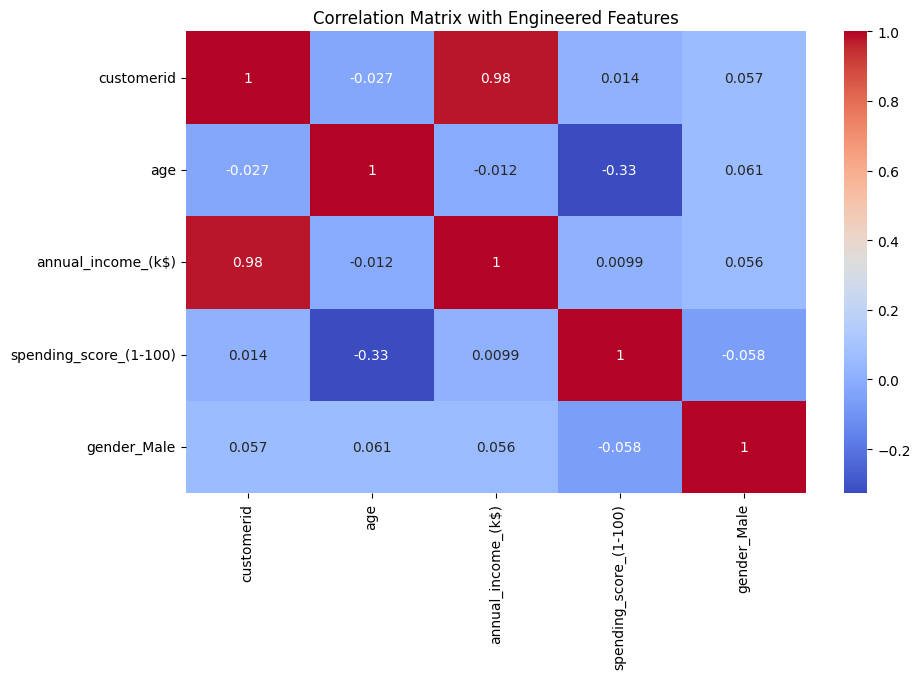

In [32]:
plt.figure(figsize=(10,6))
# Create a temporary DataFrame and one-hot encode the 'gender' column
# so that it can be included in the correlation matrix as numerical features.
df_for_corr = df.copy()
df_for_corr = pd.get_dummies(df_for_corr, columns=['gender'], drop_first=True)
sns.heatmap(df_for_corr.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Matrix with Engineered Features")
plt.show()

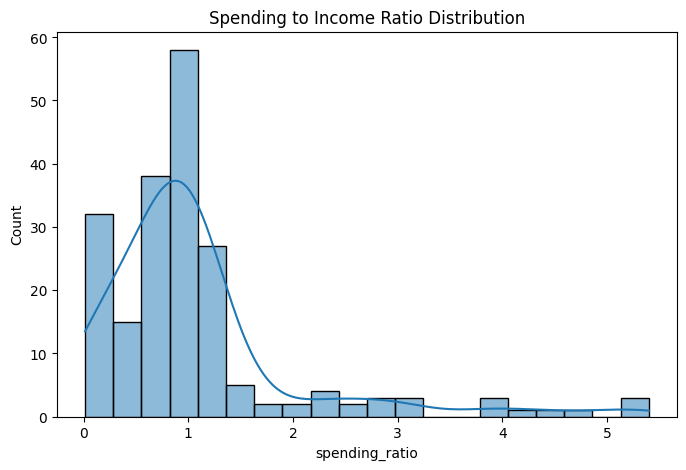

In [34]:
plt.figure(figsize=(8,5))
df['spending_ratio'] = df['spending_score_(1-100)'] / df['annual_income_(k$)']
sns.histplot(df['spending_ratio'], bins=20, kde=True)
plt.title("Spending to Income Ratio Distribution")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
df['premium_customer'] = (df['spending_score_(1-100)'] > 70).astype(int)
X = df.drop(columns=['premium_customer', 'customerid'])  # features
y = df['premium_customer']  # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Classification Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00         6

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [43]:
X_reg = df.drop(columns=['spending_score_(1-100)','customerid'])
y_reg = df['spending_score_(1-100)']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
print("Regression RMSE:", rmse)

Regression RMSE: 4.011960867206957


In [44]:
X_cluster = df.drop(columns=['customerid','premium_customer'])

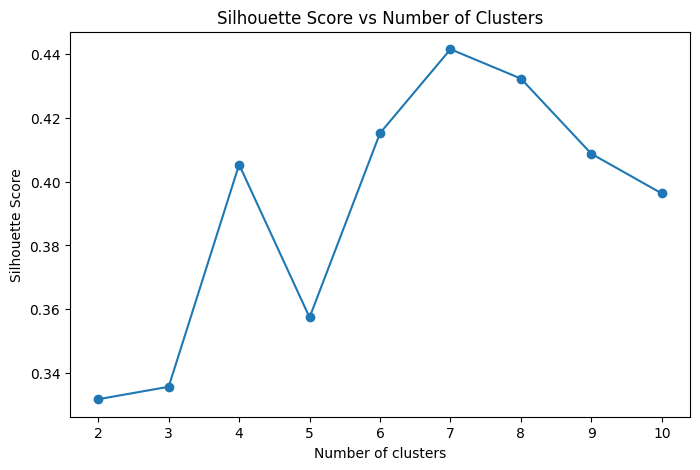

In [45]:
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))

plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

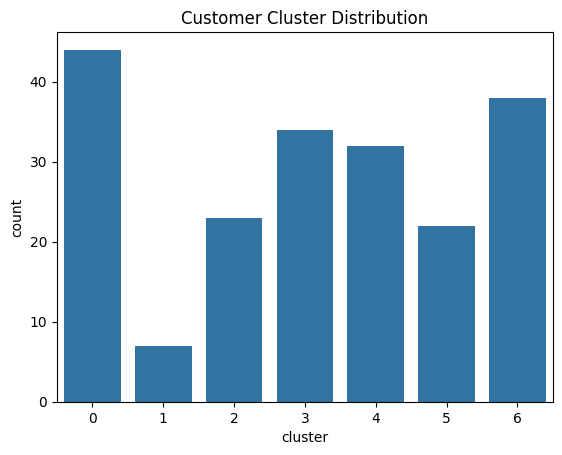

In [46]:
k_optimal = sil_scores.index(max(sil_scores)) + 2
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)
sns.countplot(x='cluster', data=df)
plt.title("Customer Cluster Distribution")
plt.show()